In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("distributed_system_architecture_stress_dataset.csv")
print(df.shape)
print(df.dtypes)


(200000, 21)
architecture_type                   str
deployment_type                     str
communication_type                  str
num_services                      int64
num_databases                     int64
requests_per_second             float64
avg_payload_kb                  float64
read_write_ratio                float64
peak_traffic_multiplier         float64
cpu_utilization_percent         float64
memory_utilization_percent      float64
network_latency_ms              float64
packet_loss_percent             float64
avg_latency_ms                  float64
p95_latency_ms                  float64
error_rate_percent              float64
db_connection_pool_exhausted      int64
retry_storm_detected              int64
circuit_breaker_open              int64
system_state                        str
root_cause                          str
dtype: object


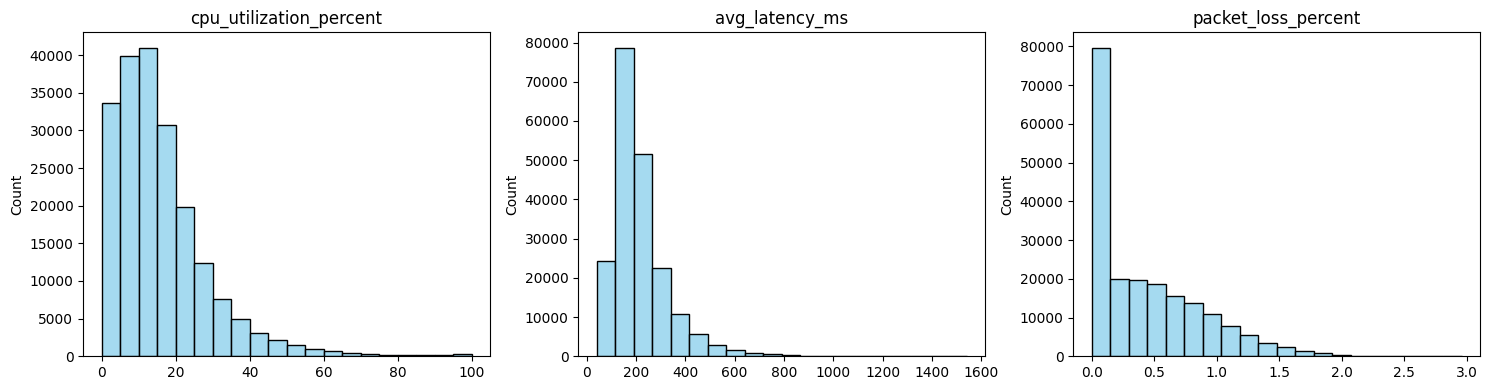

In [3]:

cols = ["cpu_utilization_percent", "avg_latency_ms", "packet_loss_percent"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

for ax, col in zip(axes, cols):
    sns.histplot(df[col], bins=20, kde=False, ax=ax, color="skyblue")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

Looking at these graphs, it seems that the variables associated with networks have a right skewed distribution. This makes sense because this is typically what you see in these systems, where the majority of values like latency and payload size are small, but exceptional cases cause high outliers.

In [ ]:
categorical_cols = ["architecture_type"]

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="system_state")
    plt.title(f"{col} vs System State")
    plt.xticks(rotation=45)
    plt.show()

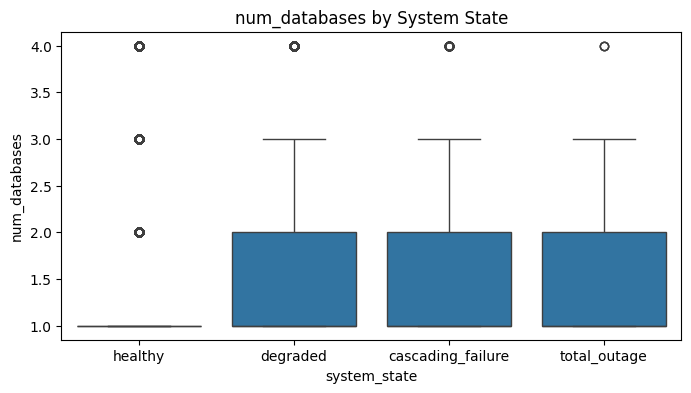

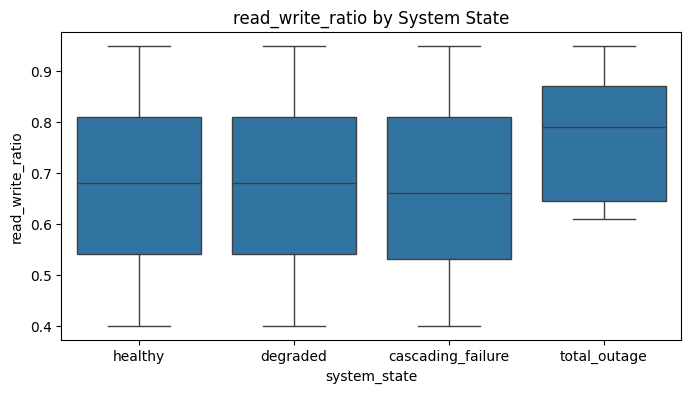

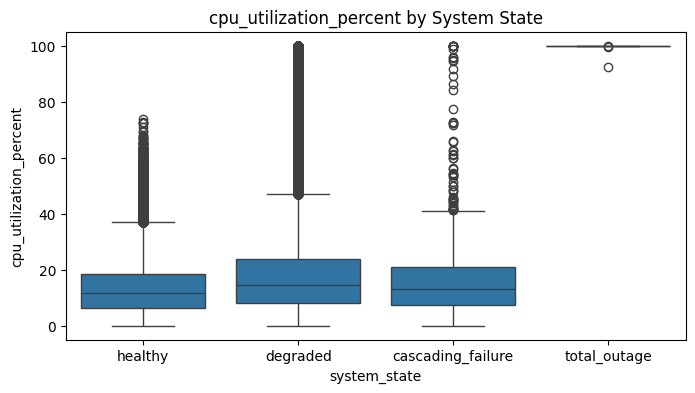

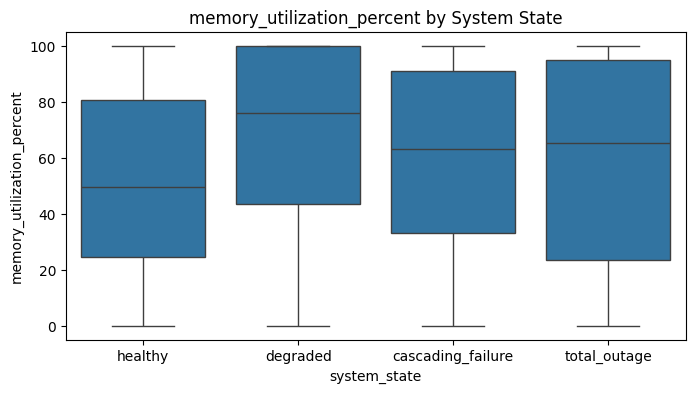

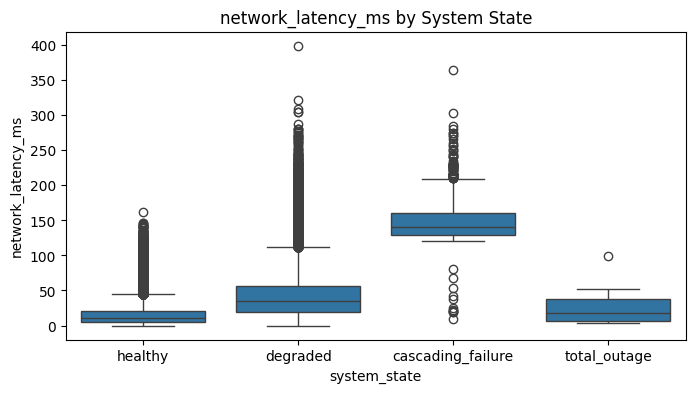

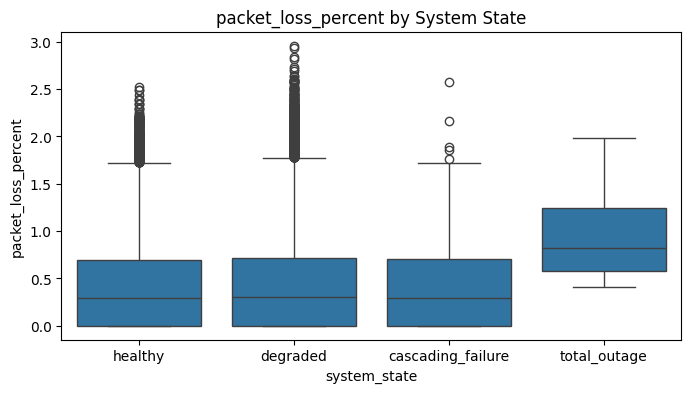

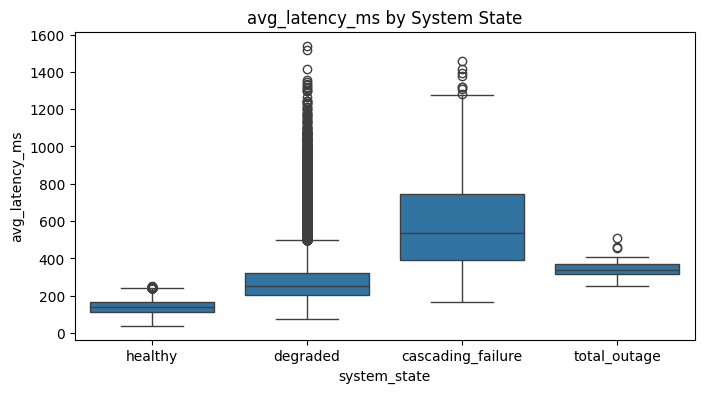

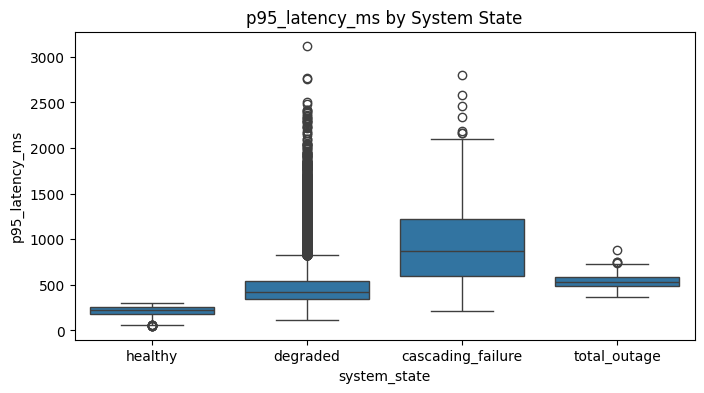

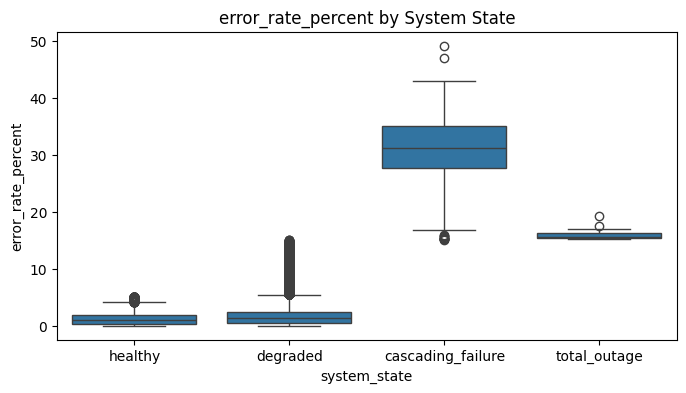

In [4]:
numeric_cols = [
    "num_databases", 
    "read_write_ratio", "cpu_utilization_percent",
    "memory_utilization_percent", "network_latency_ms", "packet_loss_percent",
    "avg_latency_ms", "p95_latency_ms", "error_rate_percent"
]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="system_state", y=col)
    plt.title(f"{col} by System State")
    plt.show()